# CharNet Detection Visualiser

Load document images alongside their CharNet JSON outputs and visualise
**word** and **character** bounding boxes interactively.

- **Word boxes** are drawn as coloured oriented polygons.
- **Character boxes** inside each word share the same colour and show the top-1 predicted character.

---

In [1]:
# ── Configuration ─────────────────────────────────────────────────────
# Point these to any input/output root pair produced by run_charnet.py.

IMAGE_ROOT  = "../data/corpus-2/imgs"   # mirrors the --input_root used
JSON_ROOT   = "../data/corpus-2/ocr/doctr/"   # mirrors the --output_root used  (adjust if different)

# Which document to inspect (subfolder name under IMAGE_ROOT / JSON_ROOT)
DOCUMENT    = "BNE_103_103_T-55310-9"

# Which page (without extension)
PAGE        = "page_0"

In [2]:
import json
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

# nice defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 8,
    "axes.titlesize": 11,
})

In [3]:
# ── Load image & detections ──────────────────────────────────────────

img_path  = Path(IMAGE_ROOT) / DOCUMENT / f"{PAGE}.png"
json_path = Path(JSON_ROOT)  / DOCUMENT / f"{PAGE}.json"

assert img_path.exists(),  f"Image not found: {img_path}"
assert json_path.exists(), f"JSON not found: {json_path}"

img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

with open(json_path) as f:
    words = json.load(f)

print(f"Image size : {img_rgb.shape[1]}×{img_rgb.shape[0]}")
print(f"Words found: {len(words)}")
print(f"Chars total: {sum(len(w.get('chars', [])) for w in words)}")

Image size : 939×1289
Words found: 170
Chars total: 1083


In [4]:
words[165]

{'tblr': [120, 153, 599, 626],
 'text': 'Y',
 'text_score': 0.9992327690124512,
 'word_bbox_score': 0.9992327690124512,
 'chars': [{'tblr': [120, 153, 599, 624],
   'labels': {'Y': 0.9999785842418781,
    'y': 1.5834885737590614e-05,
    'I': 4.190762237426628e-06,
    'X': 5.160699287326228e-07,
    'V': 3.511374264551585e-07,
    'L': 2.2479556839871433e-07,
    "'": 1.2076216056723401e-07,
    'T': 8.143578832965477e-08,
    '/': 2.7285104352560606e-08,
    'M': 1.8808497448184874e-08}}]}

In [5]:
# ── Helpers ───────────────────────────────────────────────────────────

def polygon_from_flat(coords):
    """Convert [x1,y1,x2,y2,x3,y3,x4,y4] → (4,2) array."""
    return np.array(coords, dtype=float).reshape(4, 2)


def make_colour_map(n, cmap_name="hsv"):
    """Return *n* distinct RGBA colours from a matplotlib colourmap."""
    cmap = plt.cm.get_cmap(cmap_name, max(n, 1))
    return [cmap(i) for i in range(n)]


def top1_label(labels_dict):
    """Return the character with the highest score."""
    return max(labels_dict, key=labels_dict.get)

C:\Users\diego\AppData\Local\Temp\ipykernel_3028\3393605105.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, max(n, 1))


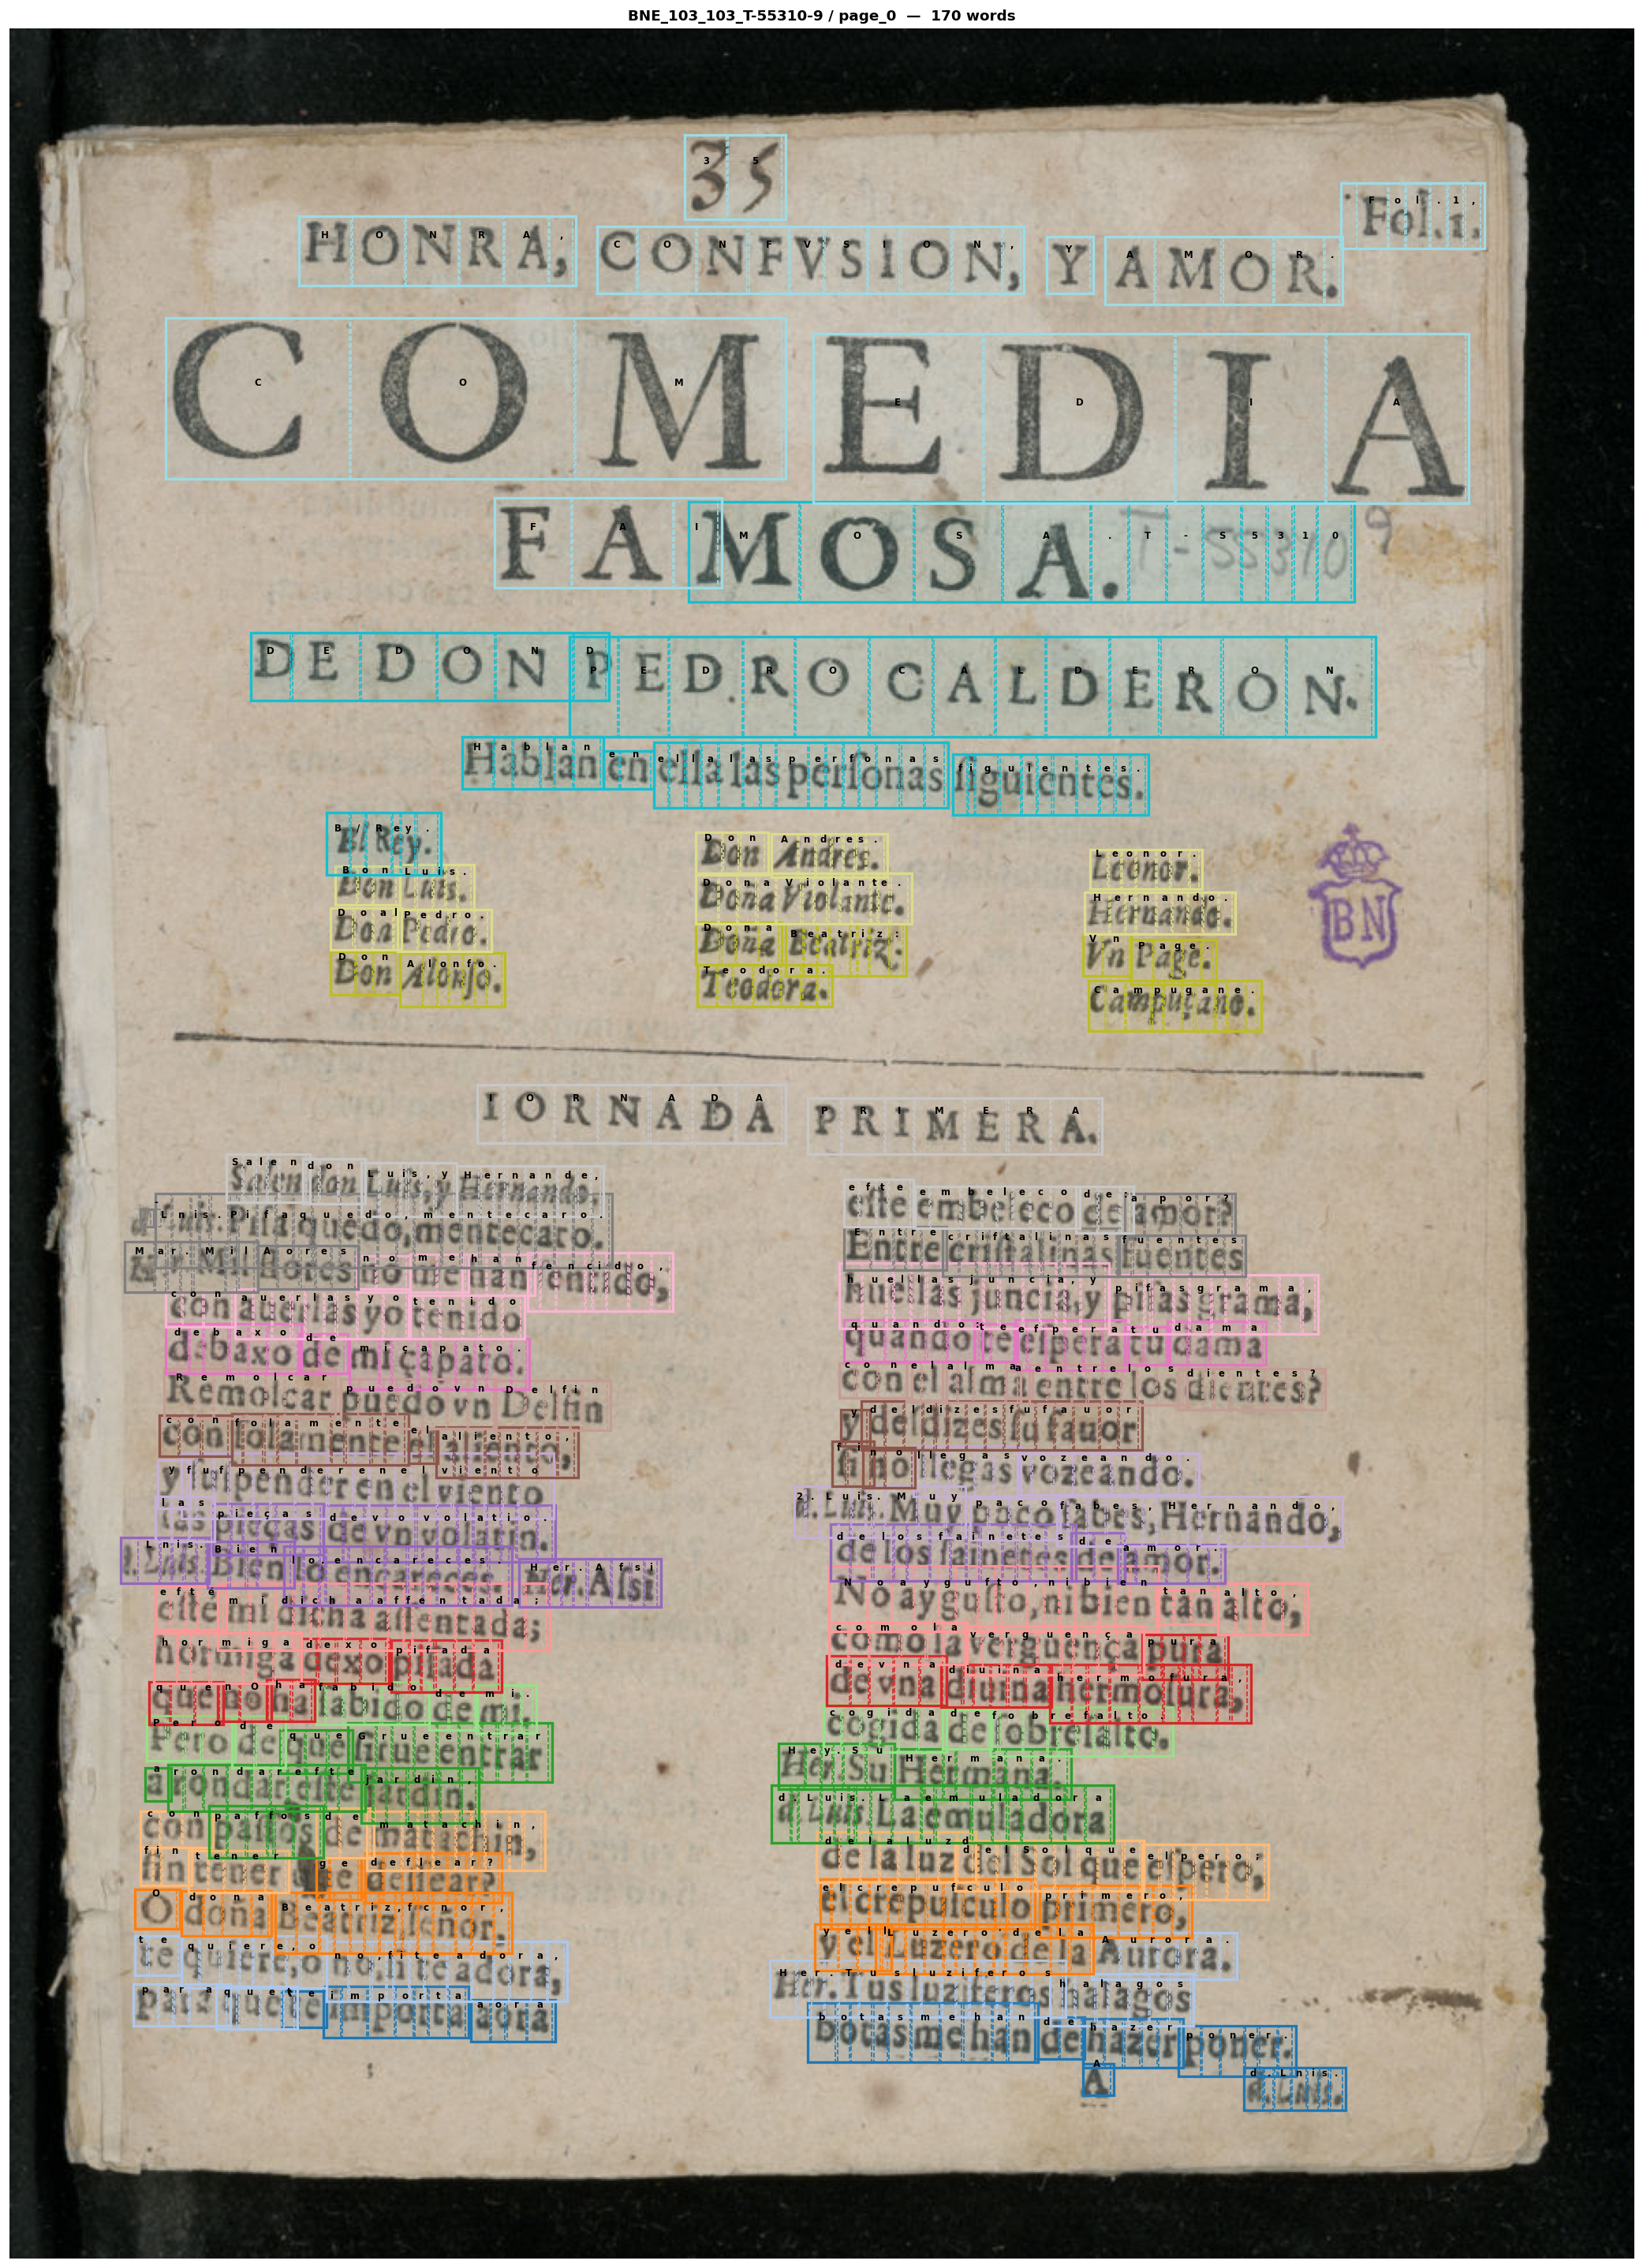

In [6]:
# ── Full-page plot: words + chars ────────────────────────────────────

colours = make_colour_map(len(words), cmap_name="tab20")

fig, ax = plt.subplots(1, 1, figsize=(24, 24))
ax.imshow(img_rgb)
ax.set_axis_off()
ax.set_title(f"{DOCUMENT} / {PAGE}  —  {len(words)} words", fontweight="bold")

for idx, word in enumerate(words):
    colour = colours[idx % len(colours)]

    # ── word polygon ──
    if "polygon" in word:
        poly = polygon_from_flat(word["polygon"])
        patch = MplPolygon(poly, closed=True,
                           linewidth=2, edgecolor=colour,
                           facecolor=(*colour[:3], 0.08))
        ax.add_patch(patch)
    elif "tblr" in word:
        tblr = word["tblr"]
        rect = mpatches.Rectangle((tblr[2], tblr[0]), tblr[3]-tblr[2], tblr[1]-tblr[0],
                                  linewidth=2, edgecolor=colour,
                                  facecolor=(*colour[:3], 0.08))
        ax.add_patch(rect)

    
    # ── character polygons ──
    for char_det in word.get("chars", []):
        if "polygon" in char_det:
            cbox = polygon_from_flat(char_det["polygon"])
            cpatch = MplPolygon(cbox, closed=True,
                                linewidth=1.0, edgecolor=colour,
                                facecolor="none", linestyle="--")
            ccx, ccy = cbox.mean(axis=0)
        elif "tblr" in char_det:
            cbox = char_det["tblr"]
            cpatch = mpatches.Rectangle((cbox[2], cbox[0]), cbox[3]-cbox[2], cbox[1]-cbox[0],
                                        linewidth=1.0, edgecolor=colour,
                                        facecolor="none", linestyle="--")
            ccx = (cbox[2] + cbox[3]) / 2
            ccy = (cbox[0] + cbox[1]) / 2
        else:
            continue  # no geometry for this char, skip
        ax.add_patch(cpatch)

        # character label
        lbl = top1_label(char_det["labels"])
        ax.text(ccx, ccy - 6, lbl,
                fontsize=7, color='k', fontweight="bold",
                ha="center", va="bottom", clip_on=True)

fig.tight_layout()
plt.show()

---
## Zoom into a region

Pick a rectangular crop (in pixels) to zoom into a specific area and see
the character-level detail more clearly.

In [7]:
# ── Crop coordinates (adjust as needed) ──────────────────────────────
X_MIN, X_MAX = 0, 500
Y_MIN, Y_MAX = 0, 500

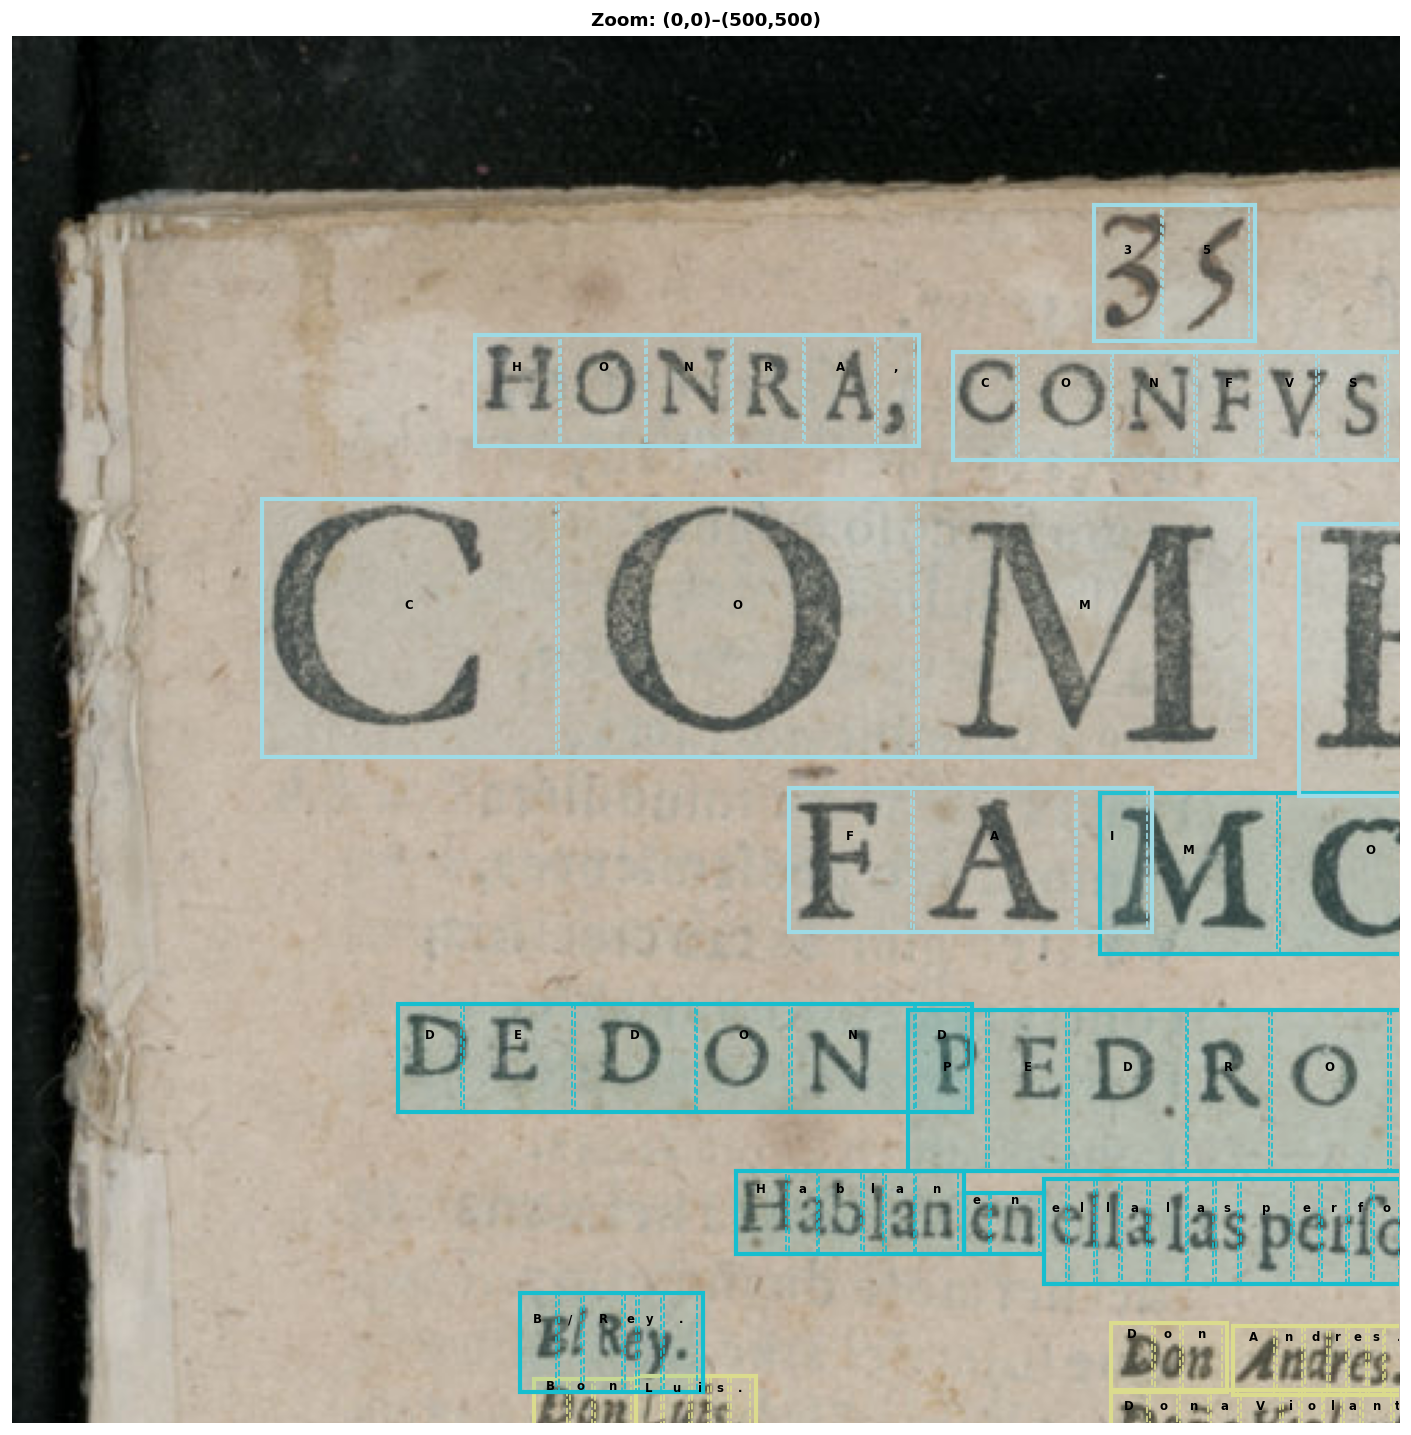

In [8]:
# ── Zoomed plot ──────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(16, 12))
ax.imshow(img_rgb)
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MAX, Y_MIN)  # y-axis is inverted in image coords
ax.set_axis_off()
ax.set_title(f"Zoom: ({X_MIN},{Y_MIN})–({X_MAX},{Y_MAX})", fontweight="bold")

for idx, word in enumerate(words):
    colour = colours[idx % len(colours)]

    if "polygon" in word:
        poly = polygon_from_flat(word["polygon"])

        # skip words completely outside the crop
        if (poly[:, 0].max() < X_MIN or poly[:, 0].min() > X_MAX or
                poly[:, 1].max() < Y_MIN or poly[:, 1].min() > Y_MAX):
            continue

        patch = MplPolygon(poly, closed=True,
                        linewidth=2.5, edgecolor=colour,
                        facecolor=(*colour[:3], 0.10))
    elif "tblr" in word:
        tblr = word["tblr"]
        x1, y1, x2, y2 = tblr[2], tblr[0], tblr[3], tblr[1]

        # skip words completely outside the crop
        if (x2 < X_MIN or x1 > X_MAX or y2 < Y_MIN or y1 > Y_MAX):
            continue

        patch = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2.5, edgecolor=colour,
                                  facecolor=(*colour[:3], 0.10))
    else:
        continue  # no geometry for this word, skip
    
    ax.add_patch(patch)


    for char_det in word.get("chars", []):
        if "polygon" in char_det:
            cbox = polygon_from_flat(char_det["polygon"])
            cpatch = MplPolygon(cbox, closed=True,
                                linewidth=1.0, edgecolor=colour,
                                facecolor="none", linestyle="--")
            ccx, ccy = cbox.mean(axis=0)
        elif "tblr" in char_det:
            cbox = char_det["tblr"]
            cpatch = mpatches.Rectangle((cbox[2], cbox[0]), cbox[3]-cbox[2], cbox[1]-cbox[0],
                                        linewidth=1.0, edgecolor=colour,
                                        facecolor="none", linestyle="--")
            ccx = (cbox[2] + cbox[3]) / 2
            ccy = (cbox[0] + cbox[1]) / 2
        else:
            continue  # no geometry for this char, skip
        ax.add_patch(cpatch)

        # character label
        lbl = top1_label(char_det["labels"])
        ax.text(ccx, ccy - 6, lbl,
                fontsize=7, color='k', fontweight="bold",
                ha="center", va="bottom", clip_on=True)

fig.tight_layout()
plt.show()